这个文档开始讨论随时间变化的时候，IRIS光谱沿着狭缝的变化

In [3]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

c:\Users\19671\anaconda3\envs\sun\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 定义高斯函数
def gaussian(x, a, x0, sigma,noise):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))+noise
def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
        return (a1 * np.exp(-(x - x1)**2 / (2 * sigma1**2)) +
                a2 * np.exp(-(x - x2)**2 / (2 * sigma2**2)) + c)
def gaussiannn(i,rsm,mu_initial):
    import numpy as np
    from scipy.optimize import curve_fit
    import matplotlib.pyplot as plt
    wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    x=wave_x[70:110]
    y=wave_y[70:110]
    # 设定初始参数
    #mu_initial = 1402.3  # 参考给定均值
    a_initial = max(y)  # 初始振幅设为 y 的最大值
    sigma_initial = 0.05  # 初始标准差
    noise_initial=0
    initial_guess = [a_initial, mu_initial, sigma_initial,noise_initial]
    # 进行高斯拟合
    popt, pcov = curve_fit(gaussian, x, y, p0=initial_guess)
    # 获取拟合参数
    a_fit, x0_fit, sigma_fit,noise_fit = popt
    sigma_fit=abs(sigma_fit)
    # 打印拟合结果
    print(f"拟合参数:")
    print(f"峰值振幅 a = {a_fit}")
    print(f"均值 μ = {x0_fit}")
    print(f"标准差 σ = {sigma_fit}")
    v1=(x0_fit-1402.77)/1402.77*299792.458
    print('多普勒速度为',v1)
    v2=sigma_fit/1402.77*299792.458
    print('速度展宽为',v2)
    # 生成拟合曲线
    x_fit = np.linspace(min(x), max(x), 1000)
    y_fit = gaussian(x_fit, *popt)
    # 绘制图像
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="point", color="red")  # 画原始数据点
    plt.plot(x_fit, y_fit, label="Gaussian", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77, color='black', linestyle='--', linewidth=1.5, label="x=1402.77")  # 画参考竖线
    plt.title("Single Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    return v1,v2

In [5]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')

In [7]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_all.npz')
doppler_vel_all = data['doppler_vel_all']
sigma_vel_all = data['sigma_vel_all']

In [ ]:
# data = np.load('doppler_sigma_velocity.npz')
# doppler_vel799 = data['doppler_vel']
# sigma_vel799 = data['sigma_vel']

# #我创建一个总的多普勒速度和速度展宽的矩阵，从797、799、。。。一直到819一共12个时刻的数据，每个时刻取110个点
# #那么创建的矩阵就都是12*110
# doppler_vel_all=np.zeros((12,110))
# sigma_vel_all=np.zeros((12,110))
# doppler_vel_all[1,:]=doppler_vel799[110:]
# sigma_vel_all[1,:]=sigma_vel799[110:]

C:\Users\19671\AppData\Local\Temp\ipykernel_12352\1416677567.py:24: OptimizeWarning: Covariance of the parameters could not be estimated
  popt,pcov=curve_fit(gaussian,x,y,p0=initial_guess)


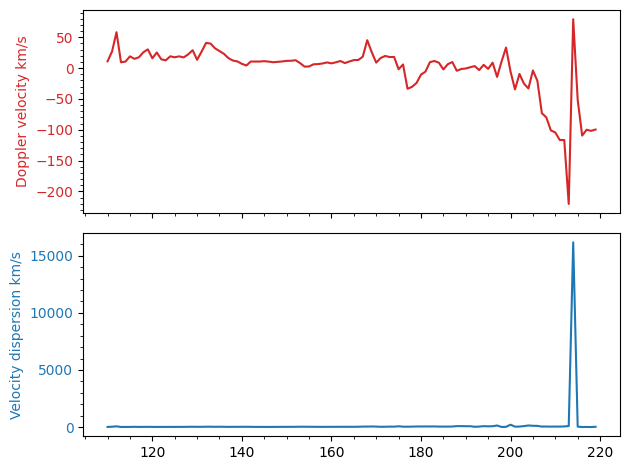

In [121]:
k=409
rsm=fits.open(file_list[k])
doppler_vel=np.zeros((110))
sigma_vel=np.zeros((110))
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
path=r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\\'+str(2*k+1)
if not os.path.exists(path):
    os.mkdir(path)
for i in range(110):
    wave_y=rsm[4].data[4,395+i*3:398+i*3,:].mean(axis=0)
    x=wave_x[70:110]
    y=wave_y[70:110]
    #初始参数
    mu_ref=1402.77
    if i>=93:
        mu_initial=1402.3
    else:
        mu_initial=1402.77
    #mu_initial=1402.77
    a_initial=np.mean(y)
    noise_initial=0
    sigma_initial=0.05
    initial_guess=[a_initial,mu_initial,sigma_initial,noise_initial]
    popt,pcov=curve_fit(gaussian,x,y,p0=initial_guess)
    #获取参数
    a_fit,mu_fit,sigma_fit,noise_fit=popt
    sigma_fit=abs(sigma_fit)
    #计算多普勒速度
    doppler_vel[i]=(mu_fit-mu_ref)/mu_ref*299792.458
    sigma_vel[i]=sigma_fit/mu_ref*299792.458
    y_fit=gaussian(x,*popt)
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label="point", color="red")  # 画原始数据点
    plt.plot(x, y_fit, label="Gaussian", color="blue")  # 画拟合曲线
    plt.axvline(x=1402.77, color='black', linestyle='--', linewidth=1.5, label="x=1402.77")  # 画参考竖线
    plt.title("Single Gaussian Fitting")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.savefig(path+'/'+str(i+110)+'.png')
    plt.close()
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)  # 创建2行1列的子图，sharex=True表示共享x轴
xrange=np.arange(110,220)
fig.subplots_adjust(hspace=0.05)  # 调整子图之间的间距
ax1.minorticks_on()
# 绘制多普勒速度
color = 'tab:red'
ax1.set_ylabel('Doppler velocity km/s', color=color)
ax1.plot(xrange,doppler_vel, color=color)
ax1.tick_params(axis='y', labelcolor=color)
# 绘制sigma的绝对值
color = 'tab:blue'
ax2.set_ylabel('Velocity dispersion km/s', color=color)
ax2.plot(xrange,sigma_vel, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.minorticks_on()
fig.tight_layout()  # 调整子图参数，使之填充整个图像区域

拟合参数:
峰值振幅 a = 12.526432442858995
均值 μ = 1401.738889992384
标准差 σ = 0.4165838589773613
多普勒速度为 -220.3632838252896
速度展宽为 89.03006126873863


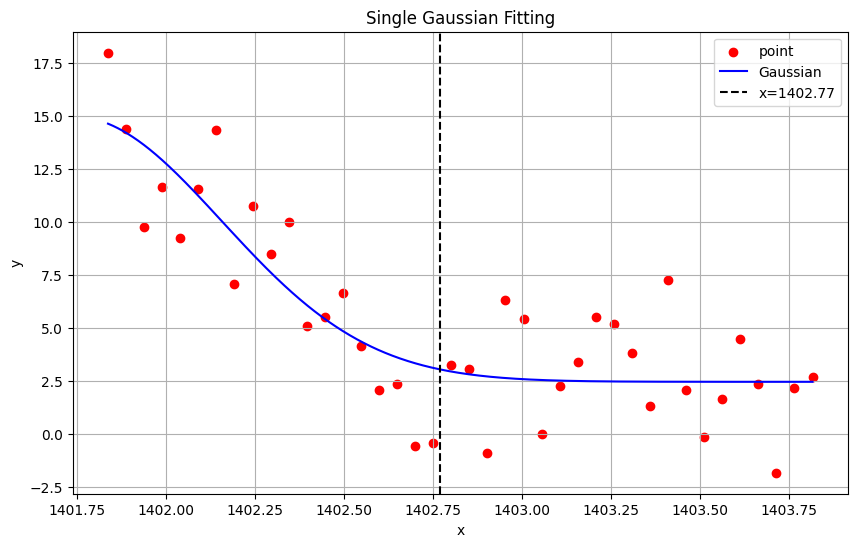

In [124]:
i=103
v1,v2=gaussiannn(i,rsm,1402.3)

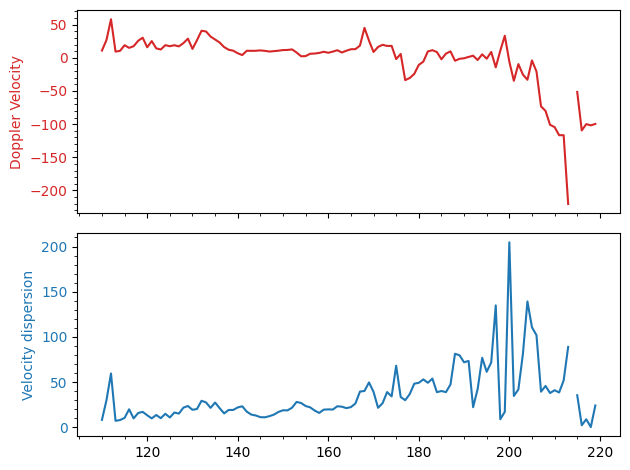

In [123]:
keyword=1
if keyword==0:
    doppler_vel[i],sigma_vel[i]=v1,v2
else:
    doppler_vel[i],sigma_vel[i]=np.nan,np.nan
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)  # 创建2行1列的子图，sharex=True表示共享x轴
fig.subplots_adjust(hspace=0.05)  # 调整子图之间的间距
ax1.minorticks_on()
# 绘制多普勒速度
color = 'tab:red'
xrange=np.arange(110,220)
ax1.set_ylabel('Doppler Velocity', color=color)
ax1.plot(xrange,doppler_vel, color=color)
ax1.tick_params(axis='y', labelcolor=color)
# 绘制sigma的绝对值
color = 'tab:blue'
ax2.set_ylabel('Velocity dispersion', color=color)
ax2.plot(xrange,sigma_vel, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.minorticks_on()
fig.tight_layout()  # 调整子图参数，使之填充整个图像区域

In [125]:
doppler_vel_all[k-398,:]=doppler_vel
sigma_vel_all[k-398,:]=sigma_vel
np.savez(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\\doppler_sigma_vel_all.npz',
         doppler_vel_all=doppler_vel_all,sigma_vel_all=sigma_vel_all)

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from IPython.display import Image
Image(filename="ang_dist.png", width=500)

In [5]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# In this case we just need to define the matter density 
# and hubble parameter at z=0.

# Note the default units for the hubble parameter H0 are km/s/Mpc. 
# We will pass in a `Quantity` object with the units specified. 

cosmo = FlatLambdaCDM(H0=70*u.km/u.s/u.Mpc, Om0=0.3)
import numpy as np
zvals = np.arange(0, 6, 0.1)
dist = cosmo.angular_diameter_distance(zvals)

In [6]:
ages = np.array([13, 10, 8, 6, 5, 4, 3, 2, 1.5, 1.2, 1])*u.Gyr
from astropy.cosmology import z_at_value
ageticks = [z_at_value(cosmo.age, age) for age in ages]

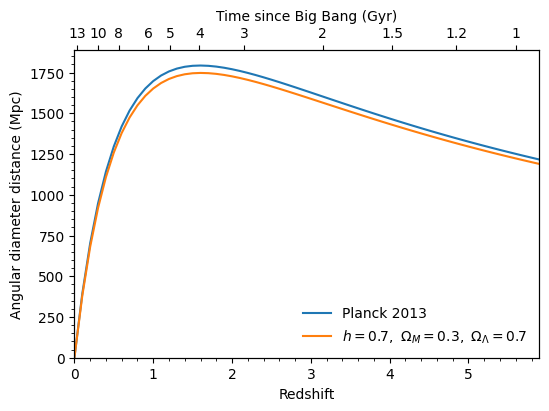

In [7]:
from astropy.cosmology import Planck13
dist2 = Planck13.angular_diameter_distance(zvals)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist2, label='Planck 2013')
ax.plot(zvals, dist, label=
        '$h=0.7,\ \Omega_M=0.3,\ \Omega_\Lambda=0.7$')
ax.legend(frameon=0, loc='lower right')
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(['{:g}'.format(age) for age in ages.value])
zmin, zmax = 0.0, 5.9
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel('Time since Big Bang (Gyr)')
ax.set_xlabel('Redshift')
ax.set_ylabel('Angular diameter distance (Mpc)')
ax.minorticks_on()
ax.set_ylim(0, 1890)
fig.savefig('ang_dist.png', dpi=200, bbox_inches='tight')

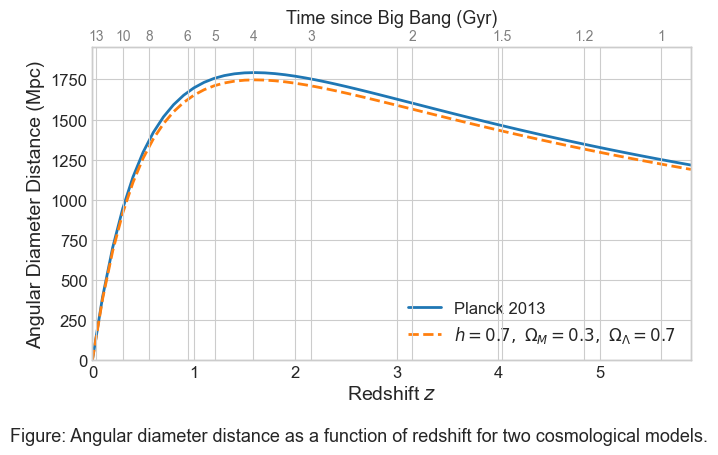

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 设置美观的样式
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14})

# 假设已有数据 zvals, dist, dist2, ageticks, ages.value
fig = plt.figure(figsize=(7, 4.5))
ax = fig.add_subplot(111)

# 主曲线
ax.plot(zvals, dist2, label='Planck 2013', color='tab:blue', linewidth=2)
ax.plot(zvals, dist, label=r'$h=0.7,\ \Omega_M=0.3,\ \Omega_\Lambda=0.7$', color='tab:orange', linestyle='--', linewidth=2)

# 图例
ax.legend(frameon=False, loc='lower right')

# 主坐标轴设置
ax.set_xlim(0.0, 5.9)
ax.set_ylim(0, 1950)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Angular Diameter Distance (Mpc)')
ax.minorticks_on()

# 次坐标轴（宇宙年龄）
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ageticks)
ax2.set_xticklabels(['{:g}'.format(age) for age in ages.value], rotation=0, fontsize=10)
ax2.set_xlabel('Time since Big Bang (Gyr)', fontsize=13)
ax2.tick_params(axis='x', colors='gray')

# 添加图注/Caption
fig.text(0.5, 0, 'Figure: Angular diameter distance as a function of redshift for two cosmological models.', 
         ha='center', fontsize=13)

# 紧凑布局 & 保存
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
fig.savefig('ang_dist_optimized.pdf', dpi=300, bbox_inches='tight')
